# Neural

Tutorial showing how to set up the Neural models

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import polars as pl

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
from morai.experience import charters, tables
from morai.forecast import metrics, preprocessors
from morai.models import neural
from morai.utils import custom_logger, helpers

In [3]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

# Data

In [4]:
test_forecast_path = helpers.ROOT_PATH / "tests" / "files" / "forecast" / "models"
sigmoid_data = pd.read_csv(test_forecast_path / "sigmoid_data.csv")
feature_dict = {
    "target": ["rate"],
    "weight": ["weight"],
    "passthrough": ["age", "gender", "faceband"],
}
preprocess_dict = preprocessors.preprocess_data(
    sigmoid_data,
    feature_dict=feature_dict,
    standardize=True,
    add_constant=False,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]

 2025-09-01 11:07:06 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-09-01 11:07:06 | morai.forecast.preprocessors | INFO     | model weights: ['weight'] 
 2025-09-01 11:07:06 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'gender', 'faceband'] 
 2025-09-01 11:07:06 | morai.forecast.preprocessors | INFO     | standardizing the data with StandardScaler 


# Comparison

## Poisson

In [5]:
model = neural.Neural(
    task="poisson",
    cat_cols=[
        "gender",
        "faceband",
    ],
)

 2025-09-01 11:07:07 | morai.models.neural | INFO     | initialized Neural model with Torch
task: poisson 
device: cpu 


In [6]:
model.fit(X=X, y=y, weights=weights, epochs=300, lr=0.001)

 2025-09-01 11:07:16 | morai.models.neural | INFO     | numeric columns: ['age'] 
 2025-09-01 11:07:16 | morai.models.neural | INFO     | categorical columns: ['gender', 'faceband'] 
 2025-09-01 11:07:16 | morai.models.neural | INFO     | dropout: 0.0 
 2025-09-01 11:07:16 | morai.models.neural | INFO     | created embeddings for `{'gender': 2, 'faceband': 2}` 
overall_mu: 0.5812747524752475


Training:   0%|          | 0/300 [00:00<?, ?it/s]

In [7]:
predictions = model.predict(X)
sigmoid_data["poisson"] = predictions

## Binomial

In [9]:
model = neural.Neural(
    task="binomial",
    cat_cols=[
        "gender",
        "faceband",
    ],
)

 2025-09-01 11:07:58 | morai.models.neural | INFO     | initialized Neural model with Torch
task: binomial 
device: cpu 


In [10]:
model.fit(X=X, y=y, weights=weights, epochs=300, lr=0.001)

 2025-09-01 11:07:59 | morai.models.neural | INFO     | numeric columns: ['age'] 
 2025-09-01 11:07:59 | morai.models.neural | INFO     | categorical columns: ['gender', 'faceband'] 
 2025-09-01 11:07:59 | morai.models.neural | INFO     | dropout: 0.0 
 2025-09-01 11:07:59 | morai.models.neural | INFO     | created embeddings for `{'gender': 2, 'faceband': 2}` 
overall_mu: 0.5812747524752475


Training:   0%|          | 0/300 [00:00<?, ?it/s]

 2025-09-01 11:07:59 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:07:59 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:07:59 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:07:59 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:08:00 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:08:00 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:08:00 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:08:00 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:08:00 | morai.models.neural | WARNING  | binomial model not tested, use with caution 
 2025-09-01 11:08:00 | morai.models.neural | WARNING  | binomial model not tested, use with

In [11]:
predictions = model.predict(X)
sigmoid_data["binomial"] = predictions

## Compare

 2025-09-01 11:08:38 | morai.experience.charters | INFO     | The weights list is 1 long and should be 3 long. Using the first weight for all weights. 


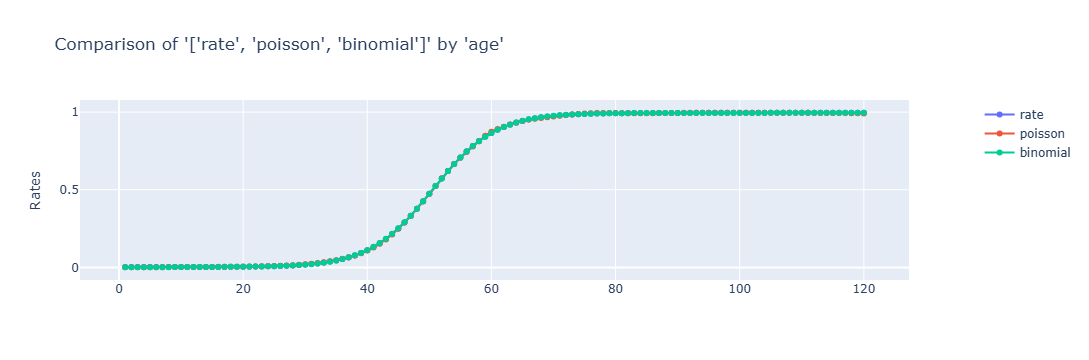

In [12]:
charters.compare_rates(
    df=sigmoid_data,
    x_axis="age",
    rates=["rate", "poisson", "binomial"],
    weights=["weight"],
    display=True,
)

# Test

In [25]:
import importlib

importlib.reload(neural)

<module 'morai.models.gam' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\models\\gam.py'>